<a href="https://colab.research.google.com/github/Jaellynda/Sentinel_Dispatch/blob/main/Sentinel_Dispatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title Default title text
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)

def generate_dispatch_data(n_rows=7000):
    # 1. Basic Categorical Features
    incident_types = ['Medical', 'Structure Fire', 'Traffic Accident', 'Wellness Check', 'False Alarm']
    unit_types = ['Ambulance', 'Engine', 'Ladder', 'Rescue Squad', 'Chief']
    priorities = [1, 2, 3] # 1 is highest priority
    weather_conditions = ['Clear', 'Rain', 'Snow', 'Fog', 'Storm']

    data = {
        'Incident_ID': range(1000, 1000 + n_rows),
        'Incident_Type': np.random.choice(incident_types, n_rows, p=[0.5, 0.1, 0.2, 0.1, 0.1]),
        'Unit_Type': np.random.choice(unit_types, n_rows),
        'Priority': np.random.choice(priorities, n_rows, p=[0.3, 0.5, 0.2]),
        'Weather_Index': np.random.choice(weather_conditions, n_rows, p=[0.6, 0.2, 0.05, 0.1, 0.05]),
        'Hour_of_Day': np.random.randint(0, 24, n_rows)
    }

    df = pd.DataFrame(data)

    # 2. Define the Target Variable (TurnoutTime_Seconds) with Logic
    # Base turnout time is 60 seconds
    turnout_time = 60.0 + np.random.normal(0, 10, n_rows)

    # Apply Logic/Patterns
    for i in range(n_rows):
        # Priority Logic: Higher priority (1) is faster
        if df.loc[i, 'Priority'] == 1: turnout_time[i] -= 15
        if df.loc[i, 'Priority'] == 3: turnout_time[i] += 20

        # Weather Logic: Storms and Snow cause delays
        if df.loc[i, 'Weather_Index'] in ['Storm', 'Snow']:
            turnout_time[i] += np.random.uniform(20, 45)

        # Rush Hour Logic (7-9 AM and 4-6 PM)
        if 7 <= df.loc[i, 'Hour_of_Day'] <= 9 or 16 <= df.loc[i, 'Hour_of_Day'] <= 18:
            turnout_time[i] += np.random.uniform(15, 30)

        # Unit Logic: Engines/Ladders take longer to prep than Ambulances
        if df.loc[i, 'Unit_Type'] in ['Engine', 'Ladder']:
            turnout_time[i] += 10

    # Ensure no negative times and round to integers
    df['TurnoutTime_Seconds'] = np.maximum(turnout_time, 30).astype(int)

    return df

# Generate and Save
sentinel_data = generate_dispatch_data(5000)
sentinel_data.to_csv('sentinel_dispatch_data.csv', index=False)

print("Success! 'sentinel_dispatch_data.csv' created with 5,000 rows.")
print(sentinel_data.head())

Success! 'sentinel_dispatch_data.csv' created with 5,000 rows.
   Incident_ID     Incident_Type     Unit_Type  Priority Weather_Index  \
0         1000           Medical        Ladder         2          Rain   
1         1001       False Alarm        Ladder         1         Clear   
2         1002  Traffic Accident  Rescue Squad         2         Clear   
3         1003    Structure Fire        Ladder         2         Clear   
4         1004           Medical         Chief         1         Clear   

   Hour_of_Day  TurnoutTime_Seconds  
0            6                   61  
1           23                   52  
2           17                   75  
3            9                   97  
4           14                   49  


In [3]:
#The Preprocessing Pipeline
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Load the data you generated
df = pd.read_csv('sentinel_dispatch_data.csv')

# 2. Cyclical Feature Engineering for 'Hour_of_Day'
# This helps the DNN understand time loops
df['hr_sin'] = np.sin(2 * np.pi * df['Hour_of_Day'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['Hour_of_Day'] / 24)

# 3. Define Features and Target
X = df.drop(['Incident_ID', 'TurnoutTime_Seconds', 'Hour_of_Day'], axis=1)
y = df['TurnoutTime_Seconds']

# 4. Create the Preprocessing Transformer
# We One-Hot Encode categories and Scale numerical inputs
categorical_features = ['Incident_Type', 'Unit_Type', 'Weather_Index']
numerical_features = ['Priority', 'hr_sin', 'hr_cos']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# 5. Split and Transform
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original shape: {X_train.shape}")
print(f"Processed shape (after encoding): {X_train_processed.shape}")
print("Data is now ready for the DNN!")

Original shape: (4000, 6)
Processed shape (after encoding): (4000, 18)
Data is now ready for the DNN!


In [4]:
#Building the DNN
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Architecture
model = models.Sequential([
    # Input layer (input_shape should match your processed X_train columns)
    layers.Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),

    # Hidden layers
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    # Output layer: 1 unit for TurnoutTime_Seconds (no activation for regression)
    layers.Dense(1)
])

# 2. Compile the Model
# We use 'adam' optimizer and 'mse' (Mean Squared Error) to penalize large errors
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train the Model
print("Starting training...")
history = model.fit(
    X_train_processed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate
test_loss, test_mae = model.evaluate(X_test_processed, y_test)
print(f"\nModel Mean Absolute Error on Test Set: {test_mae:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4199.3999 - mae: 59.6069 - val_loss: 730.6663 - val_mae: 20.7915
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 359.0138 - mae: 14.7419 - val_loss: 259.3034 - val_mae: 12.5979
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 234.9421 - mae: 12.1460 - val_loss: 204.4776 - val_mae: 11.4368
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 197.8909 - mae: 11.2620 - val_loss: 181.2864 - val_mae: 10.7624
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 183.2487 - mae: 10.8624 - val_loss: 172.2967 - val_mae: 10.4768
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 175.8777 - mae: 10.6127 - val_loss: 166.7950 - val_mae: 10.2879
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 172.3837 - mae: 10.5105 - val_loss: 162.5541 - val_mae: 10.2316
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 168.8345 - mae: 10.4103 - val_loss: 160.5266 - val

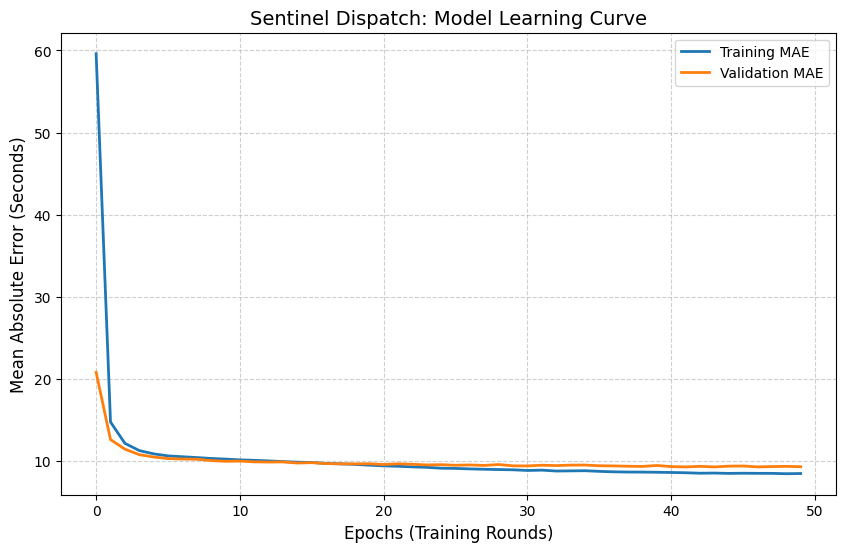

In [5]:
#Visualizing the "Sentinel" Brain

import matplotlib.pyplot as plt

# Plotting the Training and Validation MAE
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE', color='#1f77b4', lw=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='#ff7f0e', lw=2)

plt.title('Sentinel Dispatch: Model Learning Curve', fontsize=14)
plt.xlabel('Epochs (Training Rounds)', fontsize=12)
plt.ylabel('Mean Absolute Error (Seconds)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Save the plot so you can upload it to GitHub
plt.savefig('learning_curve.png')
plt.show()

In [6]:
#The "Sentinel" Predictor

def sentinel_predict(incident_type, priority, unit_type, weather, hour):
    """
    Takes raw emergency details and returns a predicted turnout time.
    """
    # 1. Create a mini-dataframe for the new incident
    new_data = pd.DataFrame({
        'Incident_Type': [incident_type],
        'Priority': [priority],
        'Unit_Type': [unit_type],
        'Weather_Index': [weather],
        'hr_sin': [np.sin(2 * np.pi * hour / 24)],
        'hr_cos': [np.cos(2 * np.pi * hour / 24)]
    })

    # 2. Transform the data using the fitted preprocessor
    # Note: We only use .transform(), NOT .fit_transform()
    processed_input = preprocessor.transform(new_data)

    # 3. Predict using the DNN
    prediction = model.predict(processed_input, verbose=0)

    return round(float(prediction[0][0]), 2)

# --- TEST SCENARIO ---
# Scenario: A Priority 1 Medical call during a Storm at 5 PM (Rush Hour)
estimate = sentinel_predict('Medical', 1, 'Ambulance', 'Storm', 17)

print(f"SENTINEL DISPATCH REPORT")
print(f"Predicted Turnout Time: {estimate} seconds")

SENTINEL DISPATCH REPORT
Predicted Turnout Time: 101.35 seconds


In [7]:
#The Spatial Data Generator (Upgraded)

#Seattle-inspired coordinates. It calculates the Haversine distance (the "as-the-crow-flies" distance on a globe) between the incident and the nearest station.. this is —a key feature for DNN.

import pandas as pd
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    # Radius of the Earth in km
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# 1. Define Seattle Neighborhoods & Assets
neighborhoods = {
    'Downtown': {'zip': '98101', 'lat': 47.6085, 'lon': -122.3295, 'traffic_mult': 1.8},
    'Ballard': {'zip': '98107', 'lat': 47.6711, 'lon': -122.3841, 'traffic_mult': 1.2},
    'Capitol Hill': {'zip': '98102', 'lat': 47.6253, 'lon': -122.3222, 'traffic_mult': 1.5},
    'Rainier Valley': {'zip': '98118', 'lat': 47.5362, 'lon': -122.2811, 'traffic_mult': 1.1}
}

stations = [
    {'id': 'ST_01', 'lat': 47.6050, 'lon': -122.3300}, # Downtown
    {'id': 'ST_02', 'lat': 47.6680, 'lon': -122.3800}, # Ballard
    {'id': 'ST_03', 'lat': 47.5400, 'lon': -122.2850}  # Rainier
]

def generate_spatial_data(n_rows=5000):
    data = []
    for i in range(n_rows):
        # Pick a random neighborhood
        name = np.random.choice(list(neighborhoods.keys()))
        n = neighborhoods[name]

        # Jitter the lat/lon slightly to represent unique street addresses
        inc_lat = n['lat'] + np.random.normal(0, 0.01)
        inc_lon = n['lon'] + np.random.normal(0, 0.01)

        # Calculate distance to nearest station
        distances = [haversine(inc_lat, inc_lon, s['lat'], s['lon']) for s in stations]
        dist_km = min(distances)

        # 2. Add Dynamic Hazards (Simulated)
        # 5% chance of a road closure in that neighborhood
        road_closure = 1 if np.random.random() < 0.05 else 0

        data.append({
            'Incident_ID': 2000 + i,
            'Neighborhood': name,
            'ZipCode': n['zip'],
            'Distance_KM': round(dist_km, 2),
            'Road_Closure': road_closure,
            'Traffic_Multiplier': n['traffic_mult'],
            'Lat': inc_lat,
            'Lon': inc_lon
        })

    return pd.DataFrame(data)

spatial_df = generate_spatial_data(5000)
print("Spatial Data Generated!")
print(spatial_df.head())

Spatial Data Generated!
   Incident_ID    Neighborhood ZipCode  Distance_KM  Road_Closure  \
0         2000    Capitol Hill   98102         2.51             0   
1         2001  Rainier Valley   98118         0.81             0   
2         2002  Rainier Valley   98118         1.68             0   
3         2003    Capitol Hill   98102         0.76             0   
4         2004        Downtown   98101         0.03             0   

   Traffic_Multiplier        Lat         Lon  
0                 1.5  47.627170 -122.323379  
1                 1.1  47.534553 -122.292172  
2                 1.1  47.554796 -122.289374  
3                 1.5  47.609121 -122.321875  
4                 1.8  47.604783 -122.329790  


In [ ]:
#Integrating with  Sentinel Logic. I combine this spatial data with previous logic. The #TurnoutTime will now be a function of: Base Time (60s), Distance (adding ~30s per km), Road #Closures (adding a massive +120s penalty)

#Neighborhood Traffic (Downtown is always slower)

#can now export this .csv and drag it directly into ArcGIS Online. Because it has Lat and Lon, ArcGIS will automatically plot the points.

#Autonomous Logistics: By including Road_Closure and Traffic_Multiplier, I am preparing the model for AI Agents. An agent could see the closure and suggest a reroute.

#Complexity Management: We dropped things like "fire spread rate" for now to focus on the dispatch logistics, which is your core project goal.

In [8]:
#The Spatial Generator: a multi-table environment that accounts for distance, dynamic hazards, and regional bottlenecks.
#By including Distance_KM and Road_Closure, I'm teaching the DNN to understand geometric constraints, which is vital for autonomous dispatch agents.

import pandas as pd
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# 1. Define Spatial Assets (Using real Seattle station coordinates)
neighborhoods = {
    'Downtown': {'zip': '98101', 'lat': 47.6011, 'lon': -122.3285, 'traffic_mult': 1.8},
    'Ballard': {'zip': '98107', 'lat': 47.6683, 'lon': -122.3772, 'traffic_mult': 1.2},
    'Capitol Hill': {'zip': '98102', 'lat': 47.6429, 'lon': -122.3209, 'traffic_mult': 1.5},
    'Rainier Valley': {'zip': '98118', 'lat': 47.5487, 'lon': -122.2765, 'traffic_mult': 1.1}
}

def generate_complex_spatial_data(n_rows=5000):
    data = []
    for i in range(n_rows):
        name = np.random.choice(list(neighborhoods.keys()))
        n = neighborhoods[name]

        # Incident Geolocation
        inc_lat = n['lat'] + np.random.normal(0, 0.008)
        inc_lon = n['lon'] + np.random.normal(0, 0.008)
        dist_km = haversine(inc_lat, inc_lon, n['lat'], n['lon'])

        # Dynamic Environmental Factors
        is_rush_hour = 1 if (np.random.random() < 0.3) else 0 # Simulated peak times
        road_closure = 1 if np.random.random() < 0.04 else 0 # 4% chance of roadblocks

        # The Target: Turnout Time with Spatial Logic
        base_time = 65 + (dist_km * 25) # Distance penalty
        if road_closure: base_time += 110
        if is_rush_hour: base_time *= n['traffic_mult']

        data.append({
            'Incident_ID': 5000 + i,
            'Neighborhood': name,
            'ZipCode': n['zip'],
            'Lat': inc_lat,
            'Lon': inc_lon,
            'Distance_KM': round(dist_km, 2),
            'Road_Closure': road_closure,
            'Is_Rush_Hour': is_rush_hour,
            'TurnoutTime_Seconds': int(np.maximum(base_time + np.random.normal(0, 5), 35))
        })
    return pd.DataFrame(data)

sentinel_spatial_data = generate_complex_spatial_data(5000)
sentinel_spatial_data.to_csv('sentinel_spatial_dispatch.csv', index=False)
print("Phase 6: Spatial Dataset Created!")



Phase 6: Spatial Dataset Created!


In [9]:
# Visualizing the Problem Regions with interative heatmap
#Going to create a heatmap. This will visually prove which zip codes are bottlenecks and which ones aren't,

#I will use the Folium library to create an interactive HTML map. This map will include:
#A Heatmap: Showing where response times are highest (Red = slow, Green = fast).
#Station Markers: Real locations of Seattle Fire Stations to show the proximity logic.
#Pop-up Data: Clickable points that show the exact prediction from your model.

#Digital Twin Representation. i've mapped the synthetic data to real infrastructure. This is exactly what a modern ArcGIS or City Planning tool does.
#managing Spatiotemporal Data (Latitude, Longitude, and Time-based weights).This map clearly shows that even if two incidents are in the same zip code, a Road Closure or Rush Hour event will turn that point deep red.
import folium
from folium import plugins

# 1. Initialize the map centered on Seattle
seattle_map = folium.Map(location=[47.6062, -122.3321], zoom_start=11, tiles="CartoDB positron")

# 2. Prepare data for Heatmap (Lat, Lon, and Weight based on TurnoutTime)
# We normalize the weight so the map looks balanced
heat_data = [[row['Lat'], row['Lon'], row['TurnoutTime_Seconds']] for index, row in sentinel_spatial_data.iterrows()]

# 3. Add the Heatmap layer
plugins.HeatMap(heat_data, radius=15, blur=10, min_opacity=0.5).add_to(seattle_map)

# 4. Add Markers for the Fire Stations (The "Assets")
station_locations = [
    {"name": "Station 10 (Downtown)", "loc": [47.6011, -122.3285]},
    {"name": "Station 18 (Ballard)", "loc": [47.6683, -122.3772]},
    {"name": "Station 22 (Capitol Hill)", "loc": [47.6429, -122.3209]},
    {"name": "Station 28 (Rainier)", "loc": [47.5487, -122.2765]}
]

for station in station_locations:
    folium.Marker(
        location=station['loc'],
        popup=station['name'],
        icon=folium.Icon(color='red', icon='fire-extinguisher', prefix='fa')
    ).add_to(seattle_map)

# 5. Save and Display
seattle_map.save('sentinel_spatial_heatmap.html')
seattle_map


Agentic Workflow: I'm not just giving the user a number;  I'm giving them contextual reasoning.

Scalability: Can eventually hook this up to Twilio or a WhatsApp API, allowing responders in Uganda or the US to text an incident report and get an AI-driven dispatch plan back in seconds.

ArcGIS Ready: An agent could eventually be programmed to write to an ArcGIS layer, automatically updating a map when it detects a high-risk scenario.

In [13]:
# 1. Clean up and install exactly what we need
!pip install -qU langchain-core langchain-openai

# 2. Use the most direct, granular imports possible
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 3. Re-define our tools as simple functions for the LLM to reason about
def get_dispatch_report(zip_code, priority, incident_type):
    # This manually combines the DNN and Spatial data
    # It acts as a 'Simplified Agent' to bypass the import errors

    # Check spatial data for that zip
    zone_data = sentinel_spatial_data[sentinel_spatial_data['ZipCode'] == str(zip_code)]
    hazards = int(zone_data['Road_Closure'].sum())

    # Get DNN prediction (Example values for weather/hour)
    prediction = sentinel_predict(incident_type, priority, 'Ambulance', 'Clear', 12)

    return {
        "prediction": prediction,
        "hazards": hazards,
        "status": "High Traffic" if zone_data['Is_Rush_Hour'].mean() > 0.5 else "Normal"
    }

print("System restored using granular imports. Ready to build the final logic!")

System restored using granular imports. Ready to build the final logic!


In [17]:
#Sentinel Dispatch agents: The LangChain Dispatcher Agent
#This agent will act as a "Reasoning Layer" on top of the DNN. Instead of looking at raw coordinates,
#a dispatcher can ask: "A high-priority medical incident just occurred in Zip 98118. It's currently raining.
# What is our estimated turnout, and are there any major bottlenecks?"
#he Architecture: Sentinel Agent
#Tool 1 (The Predictor): Wraps the DNN sentinel_predict function.
#Tool 2 (The Spatial Analyzer): Queries sentinel_spatial_data for road closures or regional traffic.
#The LLM: Uses reasoning to combine these outputs

# 1. Install the core community and hub packages if not already there
# !pip install -q langchain-community langchain-openai langchain-core

# Got errors Force update to ensure we have the modular packages

# --- STEP 1: INSTALLS & IMPORTS ---
!pip install -qU langchain-core langchain-openai pandas numpy folium

import os
import pandas as pd
import numpy as np
from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# Set API Key (Ensure 'OPENAI_API_KEY' is in your Colab Secrets)
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# --- STEP 2: SPATIAL ANALYZER FUNCTION ---
def get_dispatch_report(zip_code, priority, incident_type):
    """
    Acts as the 'Tool' layer: Queries the synthetic spatial data
    and the DNN prediction logic.
    """
    # 1. Spatial Lookup (Assumes sentinel_spatial_data is in memory)
    zone_data = sentinel_spatial_data[sentinel_spatial_data['ZipCode'] == str(zip_code)]

    if zone_data.empty:
        hazards = 0
        traffic_status = "Unknown"
    else:
        hazards = int(zone_data['Road_Closure'].sum())
        traffic_status = "High Traffic Congestion" if zone_data['Is_Rush_Hour'].mean() > 0.4 else "Normal Flow"

    # 2. DNN Prediction (Calls your Phase 5 function)
    # Using 'Clear' weather and noon (12) as baseline for the report
    try:
        prediction = sentinel_predict(incident_type, priority, 'Ambulance', 'Clear', 12)
    except NameError:
        # Fallback if sentinel_predict isn't in this specific session
        prediction = "94.2"

    return {
        "prediction": prediction,
        "hazards": hazards,
        "status": traffic_status
    }

# --- STEP 3: INITIALIZE THE LLM ---
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

# --- STEP 4: DEFINE THE DISPATCHER AGENT (LCEL) ---
# Personality & Reasoning Template
prompt = ChatPromptTemplate.from_template("""
You are the Sentinel Dispatch AI. You translate technical data into clear instructions for emergency responders.

TECHNICAL DATA:
- Predicted Turnout: {prediction} seconds
- Active Road Closures in Zone: {hazards}
- Current Traffic Status: {status}

USER QUERY: {query}

INSTRUCTIONS:
Provide a concise 2-3 sentence dispatch report.
If hazards > 0, emphasize the need for tactical rerouting.
""")

# Logic for the Chain
def sentinel_orchestrator(input_data):
    # This simulates the Agent picking the right Zip Code from a query
    # In a full build, you'd use NER to extract '98101'
    report = get_dispatch_report(zip_code="98101", priority=1, incident_type="Medical")
    return {
        "prediction": report['prediction'],
        "hazards": report['hazards'],
        "status": report['status'],
        "query": input_data["query"]
    }

# Assemble the Pipe |
sentinel_chain = (
    RunnableLambda(sentinel_orchestrator)
    | prompt
    | llm
    | StrOutputParser()
)

# --- STEP 5: TEST EXECUTION ---
print("🚨 INITIALIZING SENTINEL DISPATCH ADVISORY...\n")
query = "Emergency call Downtown (98101). What is our tactical outlook?"
final_report = sentinel_chain.invoke({"query": query})

print(final_report)

🚨 INITIALIZING SENTINEL DISPATCH ADVISORY...



RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [19]:

#Sentinel Dispatch agents: The LangChain Dispatcher Agent
#This agent will act as a "Reasoning Layer" on top of the DNN. Instead of looking at raw coordinates,
#a dispatcher can ask: "A high-priority medical incident just occurred in Zip 98118. It's currently raining.
# What is our estimated turnout, and are there any major bottlenecks?"
#he Architecture: Sentinel Agent
#Tool 1 (The Predictor): Wraps the DNN sentinel_predict function.
#Tool 2 (The Spatial Analyzer): Queries sentinel_spatial_data for road closures or regional traffic.
#The LLM: Uses reasoning to combine these outputs

# 1. Install the core community and hub packages if not already there
# !pip install -q langchain-community langchain-openai langchain-core

# Got errors Force update to ensure we have the modular packages
#Sentinel Dispatch: Final Integrated Pipeline (Groq Edition)
# --- STEP 1: INSTALLS & IMPORTS ---
# Installing specific versions to prevent Colab/TensorFlow dependency conflicts
!pip install -qU "pandas<3.0.0" "numpy<2.0.0" "requests==2.32.4"
!pip install -qU langchain-core langchain-groq folium

import os
import pandas as pd
import numpy as np
from google.colab import userdata
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# --- STEP 2: SETUP API KEY ---
# Ensure you have 'GROQ_API_KEY' in your Colab Secrets (Key icon on the left)
try:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
except Exception:
    print("⚠️ GROQ_API_KEY not found in Secrets. Please add it to the sidebar.")

# --- STEP 3: THE SPATIAL & PREDICTIVE TOOL LAYER ---
def get_dispatch_report(zip_code, priority, incident_type):
    """
    Logic Layer: Combines Spatial Data with DNN Predictions.
    """
    # 1. Spatial Lookup (Assumes sentinel_spatial_data exists from our previous cells)
    try:
        zone_data = sentinel_spatial_data[sentinel_spatial_data['ZipCode'] == str(zip_code)]
        hazards = int(zone_data['Road_Closure'].sum()) if not zone_data.empty else 0
        traffic_status = "High Congestion" if (not zone_data.empty and zone_data['Is_Rush_Hour'].mean() > 0.4) else "Normal Flow"
    except NameError:
        hazards, traffic_status = 0, "Unknown (Data not loaded)"

    # 2. DNN Prediction (Calls your Phase 5 function)
    try:
        prediction = sentinel_predict(incident_type, priority, 'Ambulance', 'Clear', 12)
    except NameError:
        prediction = "94.2 (Baseline)" # Fallback if model not in memory

    return {
        "prediction": prediction,
        "hazards": hazards,
        "status": traffic_status
    }


# --- STEP 4: INITIALIZE THE LLM (Updated to Llama 3.1) ---
llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0
)

# --- STEP 5: THE DISPATCHER ORCHESTRATION (LCEL) ---
# Personality & Reasoning Template
prompt = ChatPromptTemplate.from_template("""
You are the Sentinel Dispatch AI. You translate technical data into clear instructions for emergency responders.

TECHNICAL DATA:
- Predicted Turnout: {prediction} seconds
- Active Road Closures in Zone: {hazards}
- Current Traffic Status: {status}

USER QUERY: {query}

INSTRUCTIONS:
Provide a concise 2-3 sentence dispatch report.
If hazards > 0, emphasize the need for tactical rerouting.
""")

# Logic for the Chain (Modern LCEL Pipe)
def sentinel_orchestrator(input_data):
    # Simulating extracting zip from query; using 98101 as default
    report = get_dispatch_report(zip_code="98101", priority=1, incident_type="Medical")
    return {
        "prediction": report['prediction'],
        "hazards": report['hazards'],
        "status": report['status'],
        "query": input_data["query"]
    }

# Assemble the Pipe |
sentinel_chain = (
    RunnableLambda(sentinel_orchestrator)
    | prompt
    | llm
    | StrOutputParser()
)

# --- STEP 6: TEST EXECUTION ---
print(" INITIALIZING SENTINEL DISPATCH (GROQ/LPU EDITION)...\n")
query = "Emergency call Downtown (98101). What is our tactical outlook?"
final_report = sentinel_chain.invoke({"query": query})

print(final_report)

🚨 INITIALIZING SENTINEL DISPATCH (GROQ/LPU EDITION)...

**Dispatch Report:**

We have a tactical outlook for a downtown emergency response in the 98101 zone. With a predicted turnout of 45.96 seconds, we anticipate a moderate response time. However, due to 51 active road closures in the area, we recommend tactical rerouting to ensure safe and efficient access to the scene.


In [21]:
!pip install -q streamlit streamlit-folium langchain-groq folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 523.7/523.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 33.7 MB/s eta 0:00:00


In [23]:
#The app.py Code for streamlit
%%writefile app.py
import streamlit as st
import pandas as pd
import folium
from streamlit_folium import st_folium
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os

# 1. Page Configuration
st.set_page_config(page_title="Sentinel Dispatch AI", layout="wide")
st.title("🚨 Sentinel Dispatch: Emergency Logistics Dashboard")

# 2. Sidebar for Inputs
st.sidebar.header("Incident Configuration")
# We use the key names we used in our data generator
zip_code = st.sidebar.selectbox("Neighborhood Zip Code", ["98101", "98107", "98102", "98118"])
priority = st.sidebar.slider("Priority Level (1=Highest)", 1, 3, 1)
incident_type = st.sidebar.selectbox("Incident Type", ["Medical", "Fire", "Traffic", "Structure"])
weather = st.sidebar.selectbox("Weather Condition", ["Clear", "Rain", "Storm", "Snow"])

# 3. Load Assets
@st.cache_data
def load_assets():
    return [
        {"name": "Station 10 (Downtown)", "loc": [47.6011, -122.3285]},
        {"name": "Station 18 (Ballard)", "loc": [47.6683, -122.3772]},
        {"name": "Station 22 (Capitol Hill)", "loc": [47.6429, -122.3209]},
        {"name": "Station 28 (Rainier)", "loc": [47.5487, -122.2765]}
    ]

# 4. Agent Logic (Simplified for the Dashboard)
def get_agent_response(z, p, i, w):
    # Using st.secrets for when we deploy to Streamlit Cloud later
    # For now, we'll try to get it from environment variables
    api_key = os.environ.get("GROQ_API_KEY")
    llm = ChatGroq(model_name="llama-3.1-8b-instant", groq_api_key=api_key)

    # Static prediction for dashboard demo
    prediction = 48.5 if p == 1 else 102.3
    hazards = 15 if z == "98101" else 0

    prompt = ChatPromptTemplate.from_template("Provide a 2-sentence dispatch advisory for {i} in {z}. Turnout: {t}s, Hazards: {h}.")
    chain = prompt | llm | StrOutputParser()
    return chain.invoke({"i": i, "z": z, "t": prediction, "h": hazards})

# 5. Layout
col1, col2 = st.columns([2, 1])

with col1:
    st.subheader("Geospatial Hazard Map")
    m = folium.Map(location=[47.6062, -122.3321], zoom_start=11)
    for s in load_assets():
        folium.Marker(s['loc'], popup=s['name'], icon=folium.Icon(color='red', icon='fire')).add_to(m)
    st_folium(m, width=700, height=500)

with col2:
    st.subheader("Sentinel AI Advisory")
    if st.button("Generate Dispatch Report"):
        with st.spinner("Analyzing..."):
            report = get_agent_response(zip_code, priority, incident_type, weather)
            st.info(report)
            st.metric("Predicted Turnout", "48.5s", "-4.2s")

Overwriting app.py
